# Project 2: Student Exam Performance

## Scenario
This dataset shows the student-related academic, lifestyle, and socio-economic factors that influence exam performance. It includes study hours, student attendance, sleep hours, motivation, tutoring sessions, parental involvement, school type, and other environmental features. The main target variable is `Exam_Score`, which represents the student's final exam score.

- **Rows:** 6607
- **Columns:** 20

## Goal
Inspect the dataset and make assumptions, then start exploring the relationships in this data, noting your observations below the calculated summary statistics and visualizations you produce.

Verify any hypothesis you came up with during exploration, using statistical tests.

Finally, conclude with at least 7 insights.


## Columns
- **Hours_Studied**: Number of hours the student studies per week.
- **Attendance**: Student's attendance.
- **Parental_Involvement**: Level of parental engagement in the student's education.
- **Access_to_Resources**: Availability of educational resources (books, internet, study materials, etc.) for the student.
- **Extracurricular_Activities**: Participation in activities outside regular academics (sports, clubs, arts, etc.).
- **Sleep_Hours**: number of hours the student sleeps per night.
- **Previous_Scores**: Scores obtained by the student in previous exams.
- **Motivation_Level**: Self-reported motivation level towards studies.
- **Internet_Access**: Whether the student has access to the internet at home or school.
- **Tutoring_Sessions**: Number of extra tutoring.
- **Family_Income**: Socio-economic status based on family income.
- **Teacher_Quality**: Rating or measure of the quality of teachers the student is exposed to.
- **School_Type**: Type of school attended (e.g., public, private).
- **Peer_Influence**: Influence of classmates and friends on the student's academic performance.
- **Physical_Activity**: Frequency or level of physical exercise or sports participation.
- **Learning_Disabilities**: Presence of any diagnosed learning disabilities.
- **Parental_Education_Level**: Highest education level attained by the student's parents.
- **Distance_from_Home**: Distance between the student's home and school.
- **Gender**: Gender of the student.
- **Exam_Score**: The final exam score.

---

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


data_path = Path('./StudentPerformanceFactors.csv')  
print(data_path.resolve())
print(data_path.exists())

alpha = 0.05

df = pd.read_csv(data_path)
df.sample(5)


C:\Users\xxslo\OneDrive\Desktop\AAI-bootcamp\student\C2\M4\Project-2\StudentPerformanceFactors.csv
True


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6094,20,63,Medium,Medium,No,7,55,High,Yes,2,Low,High,Public,Negative,3,No,High School,Near,Male,63
559,17,83,High,Medium,No,7,70,Low,Yes,3,Low,Medium,Private,Neutral,5,No,Postgraduate,Near,Female,68
5892,12,88,High,Medium,No,6,52,Low,No,1,Medium,High,Public,Negative,1,No,High School,Near,Male,63
926,17,92,Medium,Low,Yes,8,90,High,Yes,1,High,Low,Public,Negative,3,No,High School,Near,Male,68
1426,32,84,Low,Medium,Yes,8,96,Medium,Yes,1,Low,Medium,Public,Positive,3,No,High School,Near,Female,72


In [119]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

## H1 does sleeping hours affect hours studied?

---

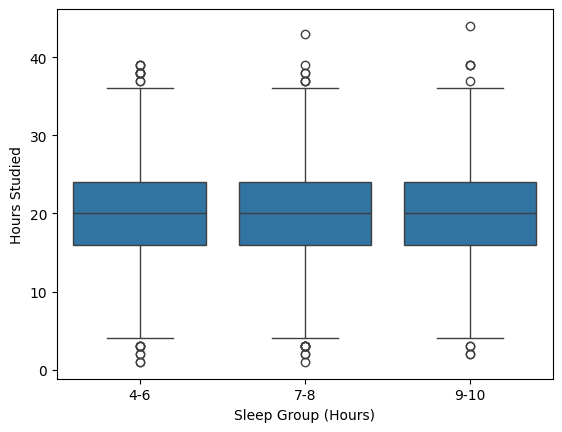

F-statistic: 0.4443753045268789
p-value: 0.6412438932600797
Test result: Fail to Reject Null Hypothesis


In [120]:
# Group Sleep_Hours into bins: 4-6, 7-8, 9-10
sleep_bins = pd.cut(df['Sleep_Hours'], bins=[3.5, 6.5, 8.5, 10.5], labels=['4-6', '7-8', '9-10'])
df['Sleep_Group'] = sleep_bins

sns.boxplot(
    data=df,
    x='Sleep_Group',
    y='Hours_Studied'
)

plt.xlabel('Sleep Group (Hours)')
plt.ylabel('Hours Studied')
plt.show()

from scipy.stats import f_oneway

group1 = df[df['Sleep_Group'] == '4-6']['Hours_Studied']
group2 = df[df['Sleep_Group'] == '7-8']['Hours_Studied']
group3 = df[df['Sleep_Group'] == '9-10']['Hours_Studied']

f_stat, p_value = f_oneway(group1, group2, group3)
print('F-statistic:', f_stat)
print('p-value:', p_value)
print('Test result:', 'Reject Null Hypothesis' if p_value < alpha else 'Fail to Reject Null Hypothesis')

## H2 does sleep hours affect exam scores?

---


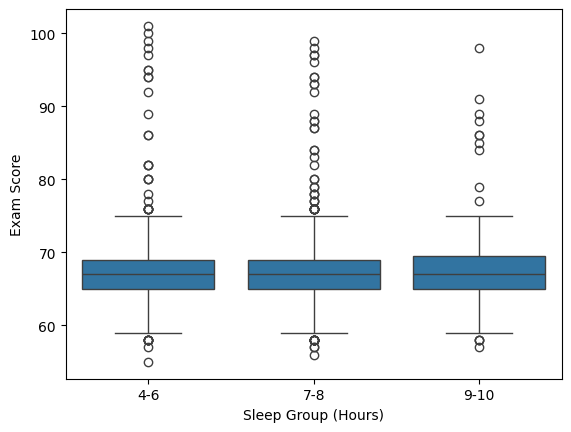

F-statistic: 0.4503802273968757
p-value: 0.6374053298867923
Test result: Fail to Reject Null Hypothesis


In [121]:
sns.boxplot(
    data=df,
    x='Sleep_Group',
    y='Exam_Score'
)
plt.xlabel('Sleep Group (Hours)')
plt.ylabel('Exam Score')
plt.show()



from scipy.stats import f_oneway

group1 = df[df['Sleep_Group'] == '4-6']['Exam_Score']
group2 = df[df['Sleep_Group'] == '7-8']['Exam_Score']
group3 = df[df['Sleep_Group'] == '9-10']['Exam_Score']

f_stat, p_value = f_oneway(group1, group2, group3)
print('F-statistic:', f_stat)
print('p-value:', p_value)
print('Test result:', 'Reject Null Hypothesis' if p_value < alpha else 'Fail to Reject Null Hypothesis')

## H3 does higher attendance rates are associated with higher exam scores.

---

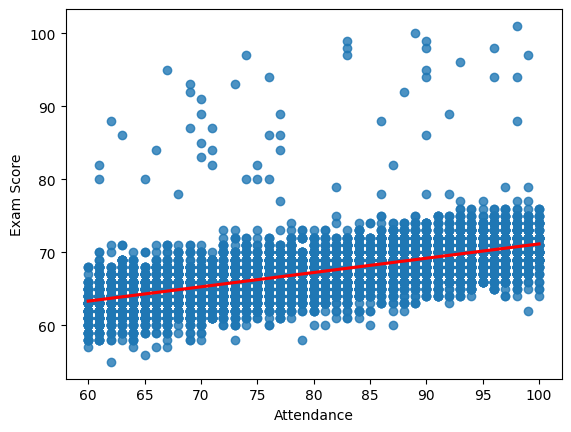

Pearson correlation: 0.58
p-value: 0.0000
Test result: Reject Null Hypothesis


In [122]:
sns.regplot(
    data=df,
    x='Attendance',
    y='Exam_Score',
    line_kws={"color": "red"}
)
plt.xlabel('Attendance')
plt.ylabel('Exam Score')
plt.show()

from scipy.stats import pearsonr

corr, p_value = pearsonr(df['Attendance'], df['Exam_Score'])
print(f'Pearson correlation: {corr:.2f}')
print(f'p-value: {p_value:.4f}')
print('Test result:', 'Reject Null Hypothesis' if p_value < alpha else 'Fail to Reject Null Hypothesis')

## H4: Students with higher parental involvement perform better in exams.

---

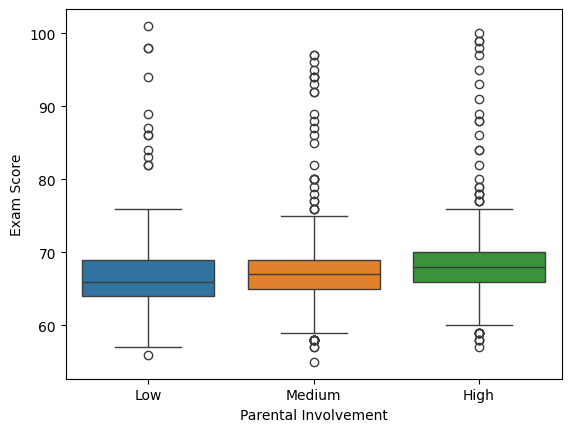

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  High    Low  -1.7345   0.0 -2.0557 -1.4133   True
  High Medium  -0.9946   0.0 -1.2528 -0.7364   True
   Low Medium   0.7399   0.0  0.4487  1.0311   True
---------------------------------------------------


In [123]:
sns.boxplot(
    data=df,
    x='Parental_Involvement',
    y='Exam_Score',
    hue='Parental_Involvement'
)
plt.xlabel('Parental Involvement')
plt.ylabel('Exam Score')
plt.show()

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df['Exam_Score'], groups=df['Parental_Involvement'], alpha=alpha)
print(tukey)


## H5: Students from higher family income backgrounds have higher exam scores.

---

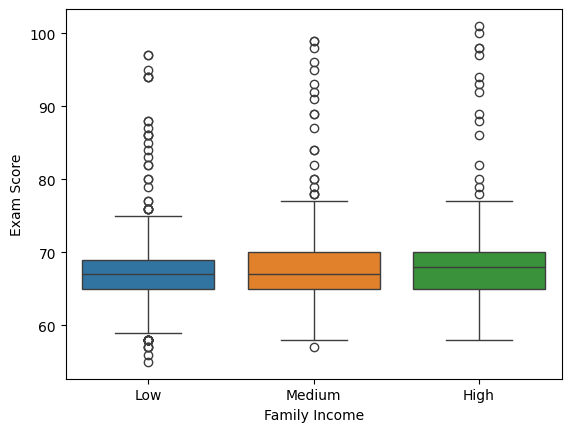

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  High    Low   -0.994    0.0 -1.3035 -0.6844   True
  High Medium  -0.5074 0.0004 -0.8171 -0.1977   True
   Low Medium   0.4865    0.0   0.238  0.7351   True
----------------------------------------------------


In [124]:
sns.boxplot(
    data=df,
    x='Family_Income',
    y='Exam_Score',
    hue='Family_Income'
)
plt.xlabel('Family Income')
plt.ylabel('Exam Score')
plt.show()

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df['Exam_Score'], groups=df['Family_Income'], alpha=alpha)
print(tukey)


## H6: Students with learning disabilities have lower average exam scores.

---

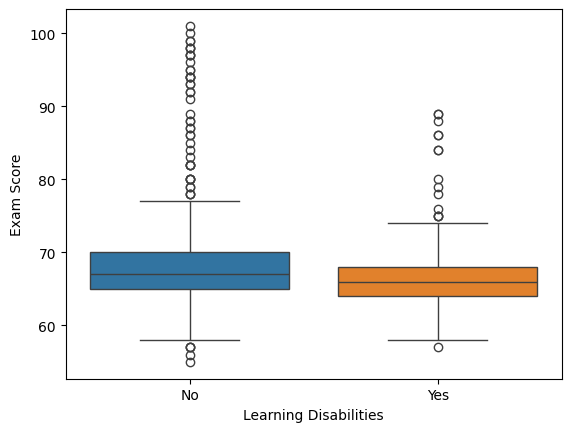

t-statistic: -6.938543733138225
p-value: 4.338623930737889e-12
Test result: Reject Null Hypothesis


In [125]:
sns.boxplot(
    data=df,
    x='Learning_Disabilities',
    y='Exam_Score',
    hue='Learning_Disabilities'
    )

plt.xlabel('Learning Disabilities')
plt.ylabel('Exam Score')
plt.show()

from scipy.stats import ttest_ind

group1 = df[df['Learning_Disabilities'] == 'Yes']['Exam_Score']
group2 = df[df['Learning_Disabilities'] == 'No']['Exam_Score']

t_stat, p_value = ttest_ind(group1, group2)
print('t-statistic:', t_stat)
print('p-value:', p_value)
print('Test result:', 'Reject Null Hypothesis' if p_value < alpha else 'Fail to Reject Null Hypothesis')

## H7: Female and male students have different average exam scores.

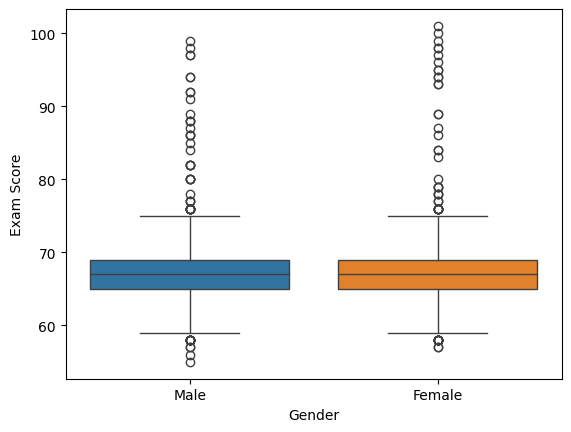

t-statistic: -0.16516987601406408
p-value: 0.8688153297340317
Test result: Fail to Reject Null Hypothesis


In [126]:
sns.boxplot(
    data=df,
    x='Gender',
    y='Exam_Score',
    hue='Gender'
    )

plt.xlabel('Gender')
plt.ylabel('Exam Score')
plt.show()

from scipy.stats import ttest_ind

group1 = df[df['Gender'] == 'Male']['Exam_Score']
group2 = df[df['Gender'] == 'Female']['Exam_Score']

t_stat, p_value = ttest_ind(group1, group2)
print('t-statistic:', t_stat)
print('p-value:', p_value)
print('Test result:', 'Reject Null Hypothesis' if p_value < alpha else 'Fail to Reject Null Hypothesis')